An autoencoder is a type of neural network used to learn efficient, compressed representations of data (called latent representations) in an unsupervised manner.

It consists of two main parts:

Encoder: Compresses the input data into a lower-dimensional representation (latent space).

Decoder: Reconstructs the original input from this compressed representation.

## MNIST dataset of circles (Vanilla autoencoders)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import TensorDataset, DataLoader

def draw_circle(radius, center_x=0.5, center_y=0.5, size=28):
    # draw a circle using coordinates for the center, and the radius
    circle = plt.Circle((center_x, center_y), radius, color='k', fill=False)
    fig, ax = plt.subplots(figsize=(1, 1))
    ax.add_patch(circle)
    ax.axis('off')
    buf = fig.canvas.print_to_buffer()  # Renders the image to a buffer (RGBA format)
    plt.close()
    # converts matplotlib figure into PIL image, make it grayscale, and resize it
    return np.array(Image.frombuffer('RGBA', buf[1], buf[0]).convert('L').resize((int(size), int(size))))

def gen_circles(n, size=28):
    # generates random coordinates around (0.5, 0.5) as center points
    center_x = np.random.uniform(0.0, 0.03, size=n).reshape(-1, 1)+.5
    center_y = np.random.uniform(0.0, 0.03, size=n).reshape(-1, 1)+.5
    # generates random radius sizes between 0.03 and 0.47
    radius = np.random.uniform(0.03, 0.47, size=n).reshape(-1, 1)
    sizes = np.ones((n, 1))*size    # Same image size for all images

    coords = np.concatenate([radius, center_x, center_y, sizes], axis=1)
    # generates circles using draw_circle function
    circles = np.apply_along_axis(func1d=lambda v: draw_circle(*v), axis=1, arr=coords)
    return circles, radius

np.random.seed(42)
# generates 1,000 circles
circles, radius = gen_circles(1000)

circles_ds = TensorDataset(torch.as_tensor(circles).unsqueeze(1).float()/255, torch.as_tensor(radius))
circles_dl = DataLoader(circles_ds, batch_size=32, shuffle=True, drop_last=True)


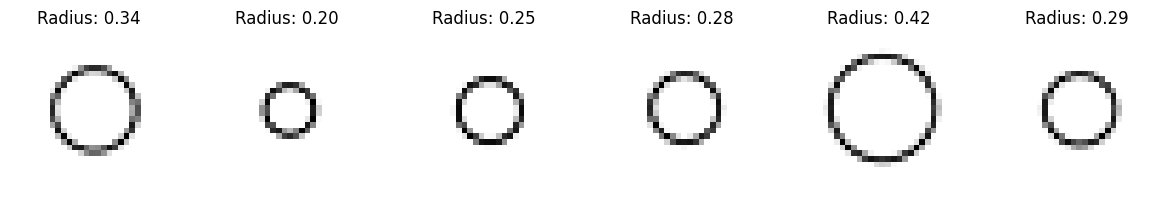

In [4]:
# Get one batch from the DataLoader
sample_batch = next(iter(circles_dl))

# Unpack the images and labels (radius values)
images, radii = sample_batch

# Plot the first 6 images from the batch
fig, axs = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axs[i].imshow(images[i][0], cmap='gray')  # images[i][0] removes channel dim (1,28,28) → (28,28)
    axs[i].set_title(f"Radius: {radii[i].item():.2f}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()


## Encoder part
The role of the encoder is to map an input (x) — 784 pixels (28x28) in our case — to a compressed representation, that is, a vector. This vector is usually denoted by the letter z, and it can be any size you want.

In [6]:
import torch.nn as nn
# reproducibility
def set_seed(seed=42):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    np.random.seed(seed)

class Encoder(nn.Module):
    def __init__(self, input_shape, z_size, base_model):
        super().__init__()
        self.input_shape = input_shape
        self.z_size = z_size
        self.base_model = base_model

        # appends the "lin_latent" linear layer to map from "output_size"
        # given by the base model to desired size of the representation (z_size)
        output_size = self._get_output_size()
        self.lin_latent = nn.Linear(output_size, z_size)

    def _get_output_size(self):
        # builds a dummy batch containing one dummy tensor , full of zeroes with the same shape as the inputs
        device = next(self.base_model.parameters()).device.type
        dummy = torch.zeros(1, *self.input_shape, device=device)
        # sends the dummy batch through the base model to get
        # the output size produced by it. This is crucial for determining the input size for the final latent projection layer.
        size = self.base_model(dummy).size(1)
        return size

    def forward(self, x):
        # forwards the input through the base model and then the "lin_latent" layer
        # to get the representation (z)
        base_out = self.base_model(x)
        out = self.lin_latent(base_out)
        return out

set_seed(13)

# we defined our representation (z) as a vector of size one
z_size = 1
# our images are 1@28x28
input_shape = (1, 28, 28) # (C, H, W)

base_model = nn.Sequential(
    # (C, H, W) -> C*H*W
    nn.Flatten(),
    # C*H*W -> 2048
    nn.Linear(np.prod(input_shape), 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
)

encoder = Encoder(input_shape, z_size, base_model)

In [7]:
x, _ = circles_ds[7] # image 7
z = encoder(x)
z

tensor([[-0.0916]], grad_fn=<AddmmBackward0>)

How do I choose the size of the latent space?”

The general idea behind an autoencoder is to obtain a compressed representation of the data through a “bottleneck” effect, so it’s only logical that the size of the latent space should be smaller than the size of the inputs.

## Decoder
opposite of encoder -> from latent space(z) to reconstructing the input(x)

In [8]:
decoder = nn.Sequential(
    # z_size -> 2048
    nn.Linear(z_size, 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
    # 2048 -> C*H*W
    nn.Linear(2048, np.prod(input_shape)),
    # C*H*W -> (C, H, W)
    nn.Unflatten(1, input_shape)
)

In [9]:
x_tilde = decoder(z)
x_tilde, x_tilde.shape

(tensor([[[[-9.2028e-02,  8.3731e-03, -3.8510e-02, -1.7983e-02,  3.1624e-02,
            -1.0687e-02,  1.0927e-01,  6.9749e-02,  7.1210e-02,  7.2251e-02,
             4.0292e-02, -1.4269e-01, -2.1248e-02, -2.2816e-01,  3.3059e-01,
             1.5166e-01,  1.4522e-01,  1.2465e-01,  3.6509e-02,  1.0319e-01,
            -2.6929e-02, -9.4624e-03,  7.7433e-03,  1.9818e-01,  2.8294e-02,
            -2.5493e-01, -8.3699e-02, -2.1312e-04],
           [ 1.0914e-01, -8.1810e-02, -6.6251e-03,  3.2857e-02,  4.7831e-02,
             1.8182e-02, -1.6559e-01,  1.3302e-02, -4.4433e-03, -7.6514e-02,
            -2.1840e-01, -5.3633e-02,  3.0588e-03,  5.9336e-03,  1.7693e-01,
             2.9944e-02, -3.8100e-02,  3.7056e-02, -4.5650e-02, -1.2820e-01,
            -1.0970e-01,  6.0889e-02, -1.8819e-02,  1.9757e-02,  1.0011e-01,
            -1.1956e-01, -1.8357e-02, -2.1009e-01],
           [ 1.1767e-01,  9.7674e-02, -1.2394e-01, -5.8676e-02,  4.5596e-02,
            -7.0251e-02, -1.5903e-01, -1.4698e-01

## Loss function
choosing loss function to minimize the negative value that were obtaining in x_tilde as pixel are not negetive
MSE or BCE

## Auto encoder

In [10]:
class AutoEncoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.enc = encoder
        self.dec = decoder

    def forward(self, x):
        # when encoder met decoder
        enc_out = self.enc(x)
        return self.dec(enc_out)  #  Objective: Minimize the difference between the output of the autoencoder and the original input image (e.g., using MSE loss).

model_ae = AutoEncoder(encoder, decoder)

In [11]:
set_seed(13)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_ae.to(device)
loss_fn = nn.MSELoss()
optim = torch.optim.Adam(model_ae.parameters(), 0.0003)

num_epochs = 10

train_losses = []

for epoch in range(1, num_epochs+1):
    batch_losses = []
    for i, (x, _) in enumerate(circles_dl):
        model_ae.train()
        x = x.to(device)

        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model_ae(x)
        # Step 2 - Computes the loss
        loss = loss_fn(yhat, x)
        # Step 3 - Computes gradients
        loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        optim.step()
        optim.zero_grad()

        batch_losses.append(np.array([loss.data.item()]))

    # Average over batches
    train_losses.append(np.array(batch_losses).mean(axis=0))

    print(f'Epoch {epoch:03d} | Loss >> {train_losses[-1][0]:.4f}')

Epoch 001 | Loss >> 0.1365
Epoch 002 | Loss >> 0.0059
Epoch 003 | Loss >> 0.0048
Epoch 004 | Loss >> 0.0048
Epoch 005 | Loss >> 0.0048
Epoch 006 | Loss >> 0.0048
Epoch 007 | Loss >> 0.0048
Epoch 008 | Loss >> 0.0049
Epoch 009 | Loss >> 0.0048
Epoch 010 | Loss >> 0.0048


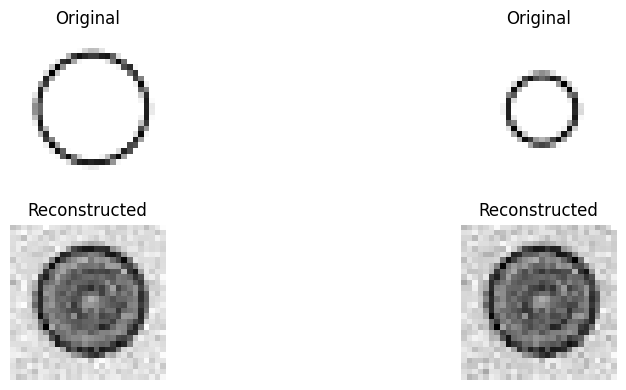

tensor([[-0.0916]], grad_fn=<AddmmBackward0>)

In [26]:
import matplotlib.pyplot as plt

# Switch model to evaluation mode
model_ae.eval()

# Get a batch from the dataloader
sample_batch, _ = next(iter(circles_dl))
sample_batch = sample_batch.to(device)

# Forward pass through autoencoder
with torch.no_grad():
    recon_batch = model_ae(sample_batch)

# Move tensors to CPU and convert to numpy
original = sample_batch.cpu().numpy()
reconstructed = recon_batch.cpu().numpy()

# Plot a few original vs. reconstructed images
n = 2  # number of images to display
plt.figure(figsize=(12, 4))

for i in range(n):
    # Original images
    plt.subplot(2, n, i + 1)
    plt.imshow(original[i][0], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed images
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i][0], cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()
z


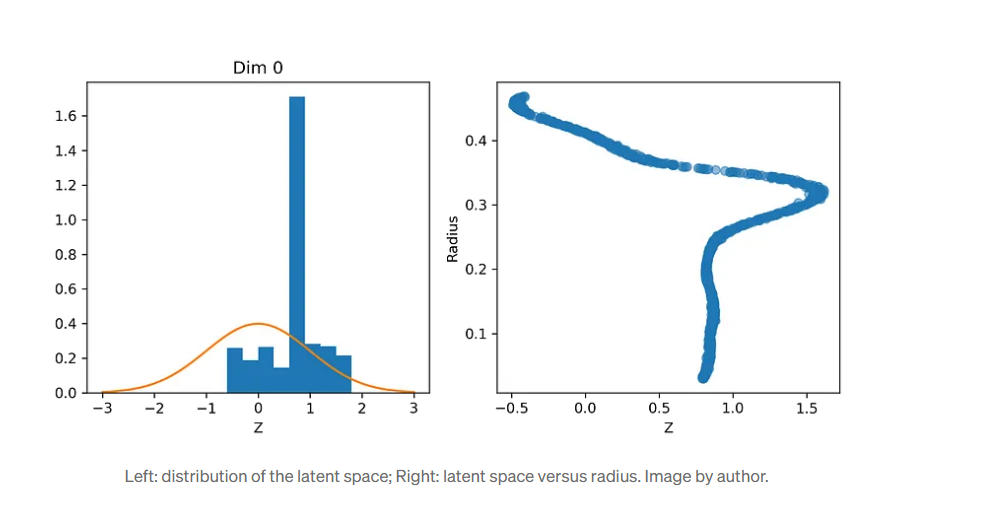

In [17]:
from IPython.display import Image, display
display(Image('/content/sample_data/i.png'))


## Interpretation:
#### Histogram of Latent Space (left plot)
The autoencoder has learned to compress a large number of distinct circle images into a narrow range of values. This causes many images to share similar latent representations, which in turn explains why reconstructions might be blurry or mixed (especially when decoding points in that congested region).

#### Latent Space vs Radius (right plot)
- The encoder did not learn a smooth or monotonic mapping from radius to latent space. It's non-linear and piecewise, suggesting:

- The model struggles to generalize across the full range of radii.

- High-density mapping in some regions (e.g., [0.6, 0.9]) limits expressiveness.

- The latent dimension isn't a clean representation of the radius, although parts of it reflect radius structure.

 ---
This imperfect latent structure is typical of vanilla autoencoders. They're not encouraged to use the latent space effectively.

Solution:
Use a Variational Autoencoder (VAE).

Use Variational Autoencoder (VAE) as -
- In traditional AE, latent space is not continous


- VAEs introduce a prior distribution (e.g., Gaussian) over the latent space.

- They regularize the encoder to spread latent vectors smoothly and consistently.

- This improves interpolation, generative quality, and latent interpretability.

#  Understanding Variational Autoencoders (VAEs)

---

##  The Problem: Why Can't We Backpropagate Through Sampling?

In a traditional autoencoder, the encoder produces a latent vector `z`, which is passed to the decoder to reconstruct the input. But a **Variational Autoencoder (VAE)** is different. Instead of producing a single latent vector, the encoder outputs two things:

- A **mean vector** `μ`
- A **variance** `σ`

We want to **sample** a latent vector `z` from a Normal distribution:


z ~ N(μ, σ²)


However, sampling is **non-differentiable**. That means gradients **cannot flow** through the random sampling step, and **the encoder cannot be trained via backpropagation**.

---

## The Solution: The Reparameterization Trick

To solve this, we use a technique called the **reparameterization trick**, which takes the random part **out** of the computation graph.

### Instead of sampling:
z ~ N(μ, σ²) # Non-differentiable

### We sample a standard normal:
ε ~ N(0, 1) # Randomness is separated

### Then reparameterize:
z = μ + ε * σ


Here, `μ` and `σ` are outputs of the encoder, and `ε` is random noise sampled from a standard normal distribution. Since `ε` is not dependent on the model's parameters, gradients can still flow through `μ` and `σ`.

---
## PyTorch Implementation

Here's how it's done in PyTorch:


```python

base_out = self.base_model(x)

self.mu = self.lin_mu(base_out)
self.log_var = self.lin_var(base_out)

std = torch.exp(self.log_var / 2)  # Convert log_var to std
eps = torch.randn_like(self.mu)    # Sample noise ε ~ N(0,1)

z = self.mu + eps * std            # Reparameterized sample








- Why Use log_var Instead of std?

Using log_var (logarithm of the variance) instead of standard deviation directly gives advantage of Ensuring positivity: Variance must be positive. Applying exp() to log_var guarantees this.

# Kullback-Leibler Divergence (KL Divergence / KL Loss)

---

## What Is KL Divergence?

The **Kullback-Leibler (KL) divergence** is a measure of how one probability distribution **differs** from another.

In the context of **Variational Autoencoders (VAEs)**, we compare:

- `p(z)`: The **learned latent distribution** from the encoder, usually a Normal distribution with learned `μ` (mean) and `σ` (standard deviation).
- `q(z)`: A **target prior distribution**, which is typically a **standard normal distribution**, i.e., `N(0, 1)`.

---

## Why Is KL Divergence Important in VAEs?

In VAEs, the KL divergence term acts as a **regularizer**. It ensures that the latent space (distribution of `z` values) remains close to a standard normal distribution.

Minimizing KL divergence helps the model learn a **smooth, continuous, and structured** latent space.

> **closer** `p(z)` is to `q(z)`, the **lower** the KL divergence.

---


##  KL Divergence in Code

Here's how to compute the KL divergence in NumPy:

```python
import numpy as np

def kl_div(mu, std):
    return -0.5 * (1 + np.log(std ** 2) - mu ** 2 - std ** 2)


In [18]:
class EncoderVar(nn.Module):
    def __init__(self, input_shape, z_size, base_model):
        super().__init__()

        self.z_size = z_size
        self.input_shape = input_shape
        self.base_model = base_model

        # Compute output size of the base_model dynamically using dummy input
        output_size = self.get_output_size()

        # Fully connected layers to generate the mean (mu) and log variance (log_var)
        self.lin_mu = nn.Linear(output_size, z_size)      # Linear layer for mean vector
        self.lin_var = nn.Linear(output_size, z_size)     # Linear layer for log variance vector

    def get_output_size(self):
        """
        Pass a dummy input through the base_model to determine the number of features
        that will be passed to the linear layers.
        """
        device = next(self.base_model.parameters()).device.type
        dummy_input = torch.zeros(1, *self.input_shape, device=device)
        output = self.base_model(dummy_input)
        return output.size(1)   # Return the flattened output feature size

    def kl_loss(self):
        """
        Computes the Kullback-Leibler divergence (KL Loss) between the learned distribution
        N(mu, sigma^2) and the standard normal distribution N(0, 1).
        Formula: -0.5 * (1 + log_var - mu^2 - exp(log_var))
        """
        kl_loss = -0.5 * (1 + self.log_var - self.mu ** 2 - torch.exp(self.log_var))
        return kl_loss

    def forward(self, x):
        """
        Forward pass through the encoder.
        Produces a latent vector z using the reparameterization trick.
        """

        # Step 1: Pass input x through the base model to extract features
        base_out = self.base_model(x)

        # Step 2: Compute mean (mu) and log variance (log_var) from the base output
        self.mu = self.lin_mu(base_out)
        self.log_var = self.lin_var(base_out)

        # Step 3: Convert log variance to standard deviation (std)
        std = torch.exp(self.log_var / 2)  # std = sqrt(exp(log_var))

        # Step 4: Sample random noise from a standard normal distribution
        eps = torch.randn_like(self.mu)

        # Step 5: Reparameterize to obtain latent vector z
        z = self.mu + eps * std

        return z


In [19]:
set_seed(13)

z_size = 1
input_shape = (1, 28, 28)

base_model = nn.Sequential(
    # (C, H, W) -> C*H*W
    nn.Flatten(),
    # C*H*W -> 2048
    nn.Linear(np.prod(input_shape), 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
)

encoder_var = EncoderVar(input_shape, z_size, base_model)

decoder_var = nn.Sequential(
    # z_size -> 2048
    nn.Linear(z_size, 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
    # 2048 -> C*H*W
    nn.Linear(2048, np.prod(input_shape)),
    # C*H*W -> (C, H, W)
    nn.Unflatten(1, input_shape)
)

model_vae = AutoEncoder(encoder_var, decoder_var)

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_vae.to(device)
loss_fn = nn.MSELoss(reduction='none')
optim = torch.optim.Adam(model_vae.parameters(), 0.0003)

num_epochs = 30

train_losses = []

reconstruction_loss_factor = 1

for epoch in range(1, num_epochs+1):
    batch_losses = []
    for i, (x, _) in enumerate(circles_dl):
        model_vae.train()
        x = x.to(device)

        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model_vae(x)

        # Step 2 - Computes the loss
        # reduce (sum) over pixels (dim=[1, 2, 3])
        # and then reduce (sum) over batch (dim=0)
        loss = loss_fn(yhat, x).sum(dim=[1, 2, 3]).sum(dim=0)
        # reduce (sum) over z (dim=1)
        # and then reduce (sum) over batch (dim=0)
        kl_loss = model_vae.enc.kl_loss().sum(dim=1).sum(dim=0)
        # we're adding the KL loss to the original MSE loss
        total_loss = reconstruction_loss_factor * loss + kl_loss

        # Step 3 - Computes gradients
        total_loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        optim.step()
        optim.zero_grad()

        batch_losses.append(np.array([total_loss.data.item(),
                                      loss.data.item(),
                                      kl_loss.data.item()]))

    # Average over batches
    train_losses.append(np.array(batch_losses).mean(axis=0))

    print(f'Epoch {epoch:03d} | Loss >> {train_losses[-1][0]:.4f}/ \
            {train_losses[-1][1]:.4f}/{train_losses[-1][2]:.4f}')

Epoch 001 | Loss >> 2050.0378/             1972.2832/77.7546
Epoch 002 | Loss >> 183.1393/             142.2218/40.9174
Epoch 003 | Loss >> 159.4892/             133.4121/26.0771
Epoch 004 | Loss >> 155.2162/             132.3413/22.8749
Epoch 005 | Loss >> 154.6435/             135.4874/19.1561
Epoch 006 | Loss >> 138.1769/             128.4872/9.6896
Epoch 007 | Loss >> 136.2148/             130.4710/5.7438
Epoch 008 | Loss >> 138.0076/             132.9441/5.0635
Epoch 009 | Loss >> 134.3012/             132.5497/1.7516
Epoch 010 | Loss >> 134.6261/             132.4423/2.1839
Epoch 011 | Loss >> 129.5194/             128.3103/1.2091
Epoch 012 | Loss >> 129.4644/             128.8459/0.6185
Epoch 013 | Loss >> 132.2849/             131.5162/0.7686
Epoch 014 | Loss >> 127.6532/             126.9433/0.7099
Epoch 015 | Loss >> 128.6145/             128.0189/0.5956
Epoch 016 | Loss >> 128.7313/             127.7177/1.0137
Epoch 017 | Loss >> 131.4526/             130.9069/0.5457
Epoch 0

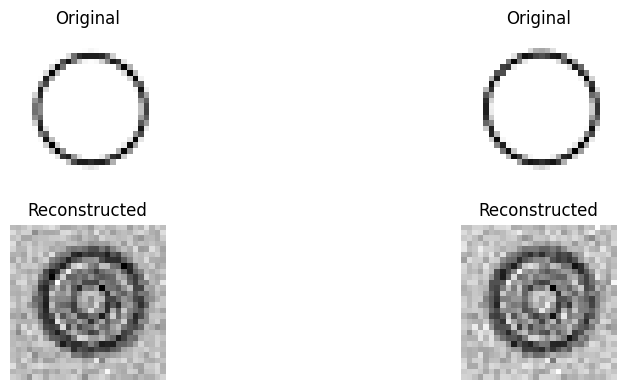

In [30]:
import matplotlib.pyplot as plt

# Switch VAE model to evaluation mode
model_vae.eval()

# Get a batch from the dataloader
sample_batch, _ = next(iter(circles_dl))
sample_batch = sample_batch.to(device)

# Forward pass through VAE (no gradients needed)
with torch.no_grad():
    recon_batch = model_vae(sample_batch)

# Move tensors to CPU and convert to numpy arrays
original = sample_batch.cpu().numpy()
reconstructed = recon_batch.cpu().numpy()

# Number of images to display
n = 2

plt.figure(figsize=(12, 4))

for i in range(n):
    # Original images
    plt.subplot(2, n, i + 1)
    plt.imshow(original[i][0], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed images
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i][0], cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()
